In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df = df.iloc[:, [3,4]]

In [5]:
df


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [6]:
df.isnull().sum()

,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,13):
  model = KMeans(n_clusters=k)
  model.fit(df)
  wcss.append(model.inertia_)

In [8]:
wcss

[269981.28000000014,
 186362.95600651755,
 106348.37306211119,
 73679.78903948837,
 44454.47647967972,
 38463.49408903115,
 31969.42655023547,
 26159.2495776581,
 22155.14949036471,
 21622.938687758677,
 18346.04844995406,
 17944.73638760785]

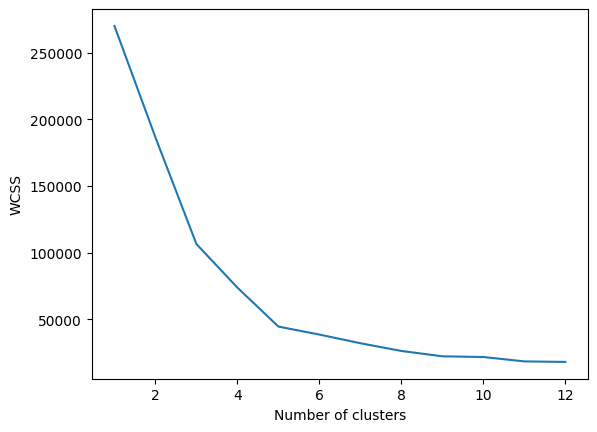

In [9]:
from matplotlib import pyplot as plt

plt.plot(range(1,13), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
model = KMeans(6,random_state=42)
cluster_labels = model.fit_predict(df)

In [11]:
cluster_labels

array([5, 2, 4, 2, 5, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 5, 2, 5, 2, 5, 2,
       4, 2, 4, 2, 5, 2, 5, 2, 4, 2, 4, 2, 4, 2, 4, 2, 5, 2, 5, 2, 5, 0,
       5, 2, 0, 5, 5, 5, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [12]:
df['Cluster'] = cluster_labels

In [13]:
df.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,5
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,5


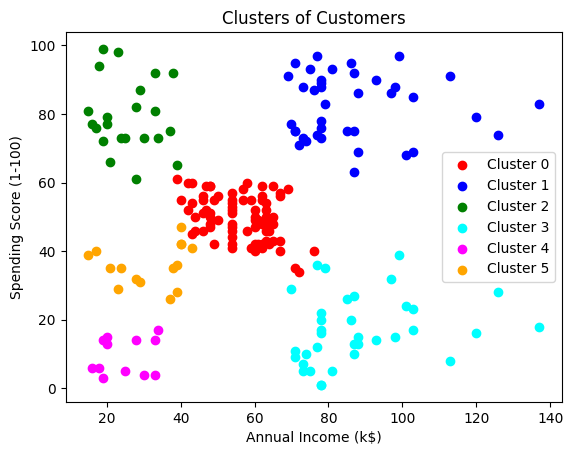

In [14]:
colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange']

for i in range(6):
  cluster_data = df[df['Cluster'] == i]
  plt.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'], label=f'Cluster {i}', color=colors[i])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters of Customers')
plt.legend()
plt.show()




In [15]:
#Blue 65k - 140k - High Income, High Spending
#cyan 80k - 140k - High Income, Low Spending
#red 40k - 75k - Average Income, Average Spending
#orange upto 40k - Low Income , Average spending
#magenta upto 25k - Low Income , Low Spending
#Green upto 40k - low income , High Spending

In [16]:
cluster_names = {
    0: 'Average Customers',
    1: 'Premium Customers',
    2: 'Impulsive Spenders',
    3: 'Careful Savers',
    4: 'Moderate Spenders',
    5: 'Budget Customers'
}

df['Segment'] = df['Cluster'].map(cluster_names)
print(df['Segment'].value_counts())

Segment
Average Customers     77
Premium Customers     39
Careful Savers        35
Impulsive Spenders    22
Budget Customers      15
Moderate Spenders     12
Name: count, dtype: int64


In [17]:
df

,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,15,39,5,Budget Customers
1,15,81,2,Impulsive Spenders
2,16,6,4,Moderate Spenders
3,16,77,2,Impulsive Spenders
4,17,40,5,Budget Customers
...,...,...,...,...
195,120,79,1,Premium Customers
196,126,28,3,Careful Savers
197,126,74,1,Premium Customers
198,137,18,3,Careful Savers
